# Proyecto Integrador M1 — Avance 2: Integración de datos externos (API de Yelp)

**Autora:** Laura Garmendia
**Empresa (caso):** InsightReach — marketing digital para negocios locales
**Ciudad analizada:** Chicago (misma ciudad filtrada en el Avance 1)

---

### Objetivo de este notebook

En el Avance 1 se limpió y describió la base de clientes. Ahora se **enriquece esa información con datos externos**: la oferta real de restaurantes de Chicago publicada en Yelp (nombre, categoría, calificación, cantidad de reseñas, nivel de precio, ubicación).

La pregunta que guía la integración es: **¿la oferta gastronómica de la ciudad coincide con lo que los clientes prefieren y con lo que pueden gastar?**

### Flujo de trabajo

| Etapa | DataFrame / archivo | Qué contiene |
|---|---|---|
| Entrada | `df_restaurantes_trans` | Clientes de Chicago limpios y transformados (mismo nombre que en el Avance 1) |
| Descarga | `yelp_chicago_raw.json` | Respuesta cruda de la API, guardada tal cual |
| Base | `df_yelp_base` | Negocios de Yelp aplanados en una tabla, sin modificar |
| Limpieza | `df_yelp_limpia` | Sin cerrados, solo Chicago, sin duplicados, precio numérico |
| Negocios únicos | `df_yelp_limpia_unicos` | Una fila por restaurante, para las estadísticas generales de la oferta |
| Integración | `df_clientes_enriquecido` | Cada cliente con la oferta de Yelp que corresponde a su perfil |

Se mantiene el mismo criterio del Avance 1: **cada etapa en su propia copia**, para que el proceso sea reproducible y auditable. Los nombres siguen la misma convención: `df_` + origen + etapa (`base`, `limpia`, `trans`), y los DataFrames que pasan de un notebook a otro conservan su nombre.

## 1. Importación de librerías

Además de las librerías del Avance 1 se usan:
- **requests**: para hacer las peticiones HTTP a la API.
- **json**: para guardar y leer la respuesta cruda de la API.
- **os / getpass**: para leer la API key de forma segura, sin escribirla en el código.
- **time**: para hacer pausas entre peticiones y no saturar la API.

> Si `requests` no estuviera instalada: `%pip install requests`

In [1]:
import os
import json
import time
from getpass import getpass

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["text.parse_math"] = False   # para que "$" y "$$" se muestren como texto y no como fórmulas

## 2. Parámetros del análisis

Todos los valores que podrían cambiar se definen en un solo lugar. Si se quisiera analizar otra ciudad, alcanza con modificar esta celda. Las rutas, el orden de los estratos y los colores tienen **los mismos nombres y valores que en el notebook del Avance 1**.

In [2]:
CIUDAD = "Chicago"
UBICACION_YELP = "Chicago, IL"          # formato "ciudad, estado" que entiende Yelp

URL_BUSQUEDA = "https://api.yelp.com/v3/businesses/search"
MAX_POR_PETICION = 50                   # máximo que devuelve Yelp por petición
MAX_POR_BUSQUEDA = 240                  # máximo total por búsqueda (usando offset)

# Archivos (los mismos nombres que en el notebook del Avance 1), en la carpeta ARCHIVOS del proyecto
CARPETA_DATOS = "../ARCHIVOS"
RUTA_LIMPIO = f"{CARPETA_DATOS}/clientes_{CIUDAD.lower()}_limpio.csv"            # entrada: salida del Avance 1
RUTA_ENRIQUECIDO = f"{CARPETA_DATOS}/clientes_{CIUDAD.lower()}_enriquecido.csv"  # salida: entrada del Avance 3
RUTA_YELP_RAW = f"{CARPETA_DATOS}/yelp_{CIUDAD.lower()}_raw.json"                # caché de la respuesta cruda de la API
RUTA_YELP_LIMPIO = f"{CARPETA_DATOS}/yelp_{CIUDAD.lower()}_negocios.csv"         # negocios de Yelp limpios

ORDEN_ESTRATO = ["Bajo", "Medio", "Alto", "Muy Alto"]
SIMBOLO_PRECIO = {1: "$", 2: "$$", 3: "$$$", 4: "$$$$"}          # nivel de precio numérico -> escala de Yelp

# Colores (los mismos que en el Avance 1)
COLOR_PRINCIPAL = "#08306b"    # dato principal
COLOR_BASE = "#b8c4d0"         # dato de referencia

### Funciones auxiliares

Las mismas funciones del Avance 1, para calcular nulos y tablas cruzadas siempre de la misma forma:
- **`resumen_nulos`:** cantidad y porcentaje de nulos por columna.
- **`tabla_cruzada`:** porcentaje de cada categoría de una variable dentro de cada categoría de otra (cada fila suma 100).

In [3]:
def resumen_nulos(df):
    """Cantidad y porcentaje de nulos por columna (solo columnas con nulos)."""
    nulos = df.isnull().sum()
    tabla = pd.DataFrame({
        "nulos": nulos,
        "porcentaje": (nulos / len(df) * 100).round(2),
    })
    return tabla[tabla["nulos"] > 0].sort_values("nulos", ascending=False)


def tabla_cruzada(df, filas, columnas):
    """% de cada categoría de `columnas` dentro de cada categoría de `filas` (cada fila suma 100)."""
    return (pd.crosstab(df[filas], df[columnas], normalize="index") * 100).round(1)

## 3. Carga de los clientes limpios (Avance 1)

Se parte del CSV exportado al final del Avance 1, así no se repite la limpieza. El DataFrame conserva **el mismo nombre que tenía allí**, `df_restaurantes_trans`, para que se vea de inmediato de dónde viene. Al guardar en CSV se pierden los tipos `category` y el orden del estrato, por eso se vuelven a definir.

In [4]:
df_restaurantes_trans = pd.read_csv(RUTA_LIMPIO, dtype={"id_persona": str})

df_restaurantes_trans["estrato_socioeconomico"] = pd.Categorical(
    df_restaurantes_trans["estrato_socioeconomico"], categories=ORDEN_ESTRATO, ordered=True
)

print(f"Clientes cargados: {len(df_restaurantes_trans):,}")
print("Nulos:", df_restaurantes_trans.isnull().sum().sum())
df_restaurantes_trans.head(3)

Clientes cargados: 5,384
Nulos: 0


,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales,rango_edad
0,3456521319,Richard,Adams,61,Masculino,Chicago,Medio,2,23.02,Sí,Sí,Vegetariano,No,(394)853-1965,Dato no cargado,Efectivo,2838,55-64
1,2916502228,Leah,Cooper,44,Femenino,Chicago,Bajo,3,5.07,No,Sí,Mariscos,No,Dato no cargado,Dato no cargado,App,1365,35-44
2,5736368501,Jennifer,Richardson,54,Femenino,Chicago,Alto,5,34.35,No,Sí,Carnes,Sí,Dato no cargado,Dato no cargado,Tarjeta,7133,45-54


## 4. Conexión con la API de Yelp

### 4.1 ¿Cómo funciona la API?

La **Yelp Fusion API** (hoy llamada *Yelp Places API*) es una API REST: se le hace una petición `GET` a una URL con parámetros y devuelve la respuesta en formato **JSON**. El endpoint usado es `/v3/businesses/search`, que busca negocios por ubicación y categoría.

Características que condicionan el diseño del código:
- **Autenticación:** cada petición lleva la API key en el encabezado `Authorization: Bearer <clave>`.
- **Paginación:** devuelve como máximo **50 negocios por petición** y **240 por búsqueda**. Para obtener más de 50 se usa el parámetro `offset` (desde qué resultado empezar).
- **Cupo limitado:** el plan de prueba tiene un número limitado de llamadas; si se supera, la API responde con el código `429`.
- **Solo devuelve negocios con al menos una reseña.**

### 4.2 Manejo seguro de la API key

**La API key nunca se escribe en el notebook**, porque el proyecto se comparte de forma pública y cualquiera podría usarla (y consumir el cupo). Se lee de una variable de entorno `YELP_API_KEY` y, si no existe, se pide por teclado con `getpass`, que no la muestra en pantalla ni la guarda en la salida de la celda.

> Para definir la variable de entorno antes de abrir Jupyter:
> - Windows (PowerShell): `$env:YELP_API_KEY="tu_clave"`
> - Mac/Linux: `export YELP_API_KEY="tu_clave"`

### 4.3 Caché de la respuesta

La respuesta de la API se guarda en `yelp_chicago_raw.json`. Si ese archivo existe, el notebook **lo lee en lugar de volver a llamar a la API**. Esto aporta:
- **Reproducibilidad:** quien evalúe el proyecto puede ejecutar el notebook sin tener una API key, con exactamente los mismos datos.
- **Ahorro de cupo:** no se gastan llamadas cada vez que se reinicia el kernel.
- **Trazabilidad:** queda un registro de los datos tal como llegaron de la fuente.

> Para forzar una descarga nueva, borrar el archivo `yelp_chicago_raw.json` de la carpeta `ARCHIVOS`.

In [5]:
def obtener_api_key():
    """Lee la API key de la variable de entorno o la pide de forma oculta."""
    clave = os.environ.get("YELP_API_KEY")
    if not clave:
        clave = getpass("Ingresá tu API key de Yelp (no se mostrará): ")
    return clave.strip()


def armar_encabezados(api_key):
    return {"Authorization": f"Bearer {api_key}", "accept": "application/json"}

### 4.4 Prueba de conexión

Antes de descargar todo se hace **una sola petición** para verificar que la clave funciona. Se revisa el **código de estado HTTP**: `200` significa éxito, `401` clave inválida, `429` cupo agotado, `400` parámetros incorrectos.

In [6]:
def probar_conexion(encabezados):
    parametros = {"location": UBICACION_YELP, "categories": "restaurants", "limit": 1}
    respuesta = requests.get(URL_BUSQUEDA, headers=encabezados, params=parametros, timeout=15)

    print("Código de estado:", respuesta.status_code)
    if respuesta.status_code == 200:
        datos = respuesta.json()
        print("Conexión exitosa. Restaurantes en", UBICACION_YELP, "según Yelp:", datos.get("total"))
        return True
    print("Error:", respuesta.text[:300])
    return False


usar_cache = os.path.exists(RUTA_YELP_RAW)

if usar_cache:
    print(f"Se encontró '{RUTA_YELP_RAW}': se usarán los datos guardados (no se llama a la API).")
else:
    encabezados = armar_encabezados(obtener_api_key())
    conexion_ok = probar_conexion(encabezados)

Se encontró '../ARCHIVOS/yelp_chicago_raw.json': se usarán los datos guardados (no se llama a la API).


## 5. Estrategia de extracción: buscar según las preferencias de los clientes

En lugar de descargar "restaurantes en general", se busca la oferta de **cada preferencia alimenticia** registrada en la base de clientes. Así los datos externos quedan conectados desde el origen con una variable del dataset principal, y la integración tiene sentido de negocio.

Para cada preferencia se eligieron las categorías de Yelp equivalentes (los *alias* oficiales de Yelp):

| Preferencia del cliente | Categorías de Yelp | Comentario |
|---|---|---|
| Carnes | `steak`, `bbq` | Parrillas y barbacoa |
| Vegetariano | `vegetarian` | |
| Vegano | `vegan` | |
| Mariscos | `seafood` | Yelp agrupa mariscos y pescados en *seafood* |
| Pescado | `sushi`, `fishnchips` | Opciones centradas en pescado, para diferenciarlo de mariscos |
| Otro | `restaurants` | Oferta general de restaurantes |

**Limitación a tener en cuenta:** las categorías de Yelp no coinciden exactamente con las de la base (en Yelp, mariscos y pescado comparten categoría). La equivalencia es una aproximación razonable y queda documentada.

In [7]:
MAPEO_CATEGORIAS = {
    "Carnes": "steak,bbq",
    "Vegetariano": "vegetarian",
    "Vegano": "vegan",
    "Mariscos": "seafood",
    "Pescado": "sushi,fishnchips",
    "Otro": "restaurants",
}

### 5.1 Función de búsqueda con paginación

La función pide los resultados de a 50, avanzando el `offset` (0, 50, 100, …) hasta llegar al máximo de 240 o hasta que no haya más resultados. Además:
- Guarda el campo **`total`**, que indica cuántos negocios existen realmente en esa categoría (aunque la API solo entregue 240). Este dato es clave para medir el **tamaño real de la oferta**.
- Hace una **pausa** entre peticiones para no saturar la API.
- **Maneja errores:** si la API responde `429` (cupo agotado) se detiene y conserva lo descargado hasta ese momento.

In [8]:
def buscar_negocios(encabezados, categorias, ubicacion=UBICACION_YELP, max_resultados=MAX_POR_BUSQUEDA):
    """Descarga hasta `max_resultados` negocios de Yelp para las categorías indicadas."""
    negocios, total = [], None
    offset = 0

    while offset < max_resultados:
        parametros = {
            "location": ubicacion,
            "categories": categorias,
            "limit": min(MAX_POR_PETICION, max_resultados - offset),
            "offset": offset,
            "sort_by": "best_match",
        }
        respuesta = requests.get(URL_BUSQUEDA, headers=encabezados, params=parametros, timeout=15)

        if respuesta.status_code == 429:
            print("  Cupo de la API agotado: se conserva lo descargado hasta ahora.")
            break
        if respuesta.status_code != 200:
            print(f"  Error {respuesta.status_code}: {respuesta.text[:200]}")
            break

        datos = respuesta.json()
        total = datos.get("total", total)
        pagina = datos.get("businesses", [])
        if not pagina:                 # no hay más resultados
            break

        negocios.extend(pagina)
        offset += len(pagina)
        time.sleep(0.3)                # pausa entre peticiones

    return {"categorias": categorias, "total": total, "negocios": negocios}

### 5.2 Descarga (o lectura del caché)

In [9]:
if usar_cache:
    with open(RUTA_YELP_RAW, encoding="utf-8") as archivo:
        respuestas_yelp = json.load(archivo)
elif conexion_ok:
    respuestas_yelp = {}
    for preferencia, categorias in MAPEO_CATEGORIAS.items():
        print(f"Buscando '{preferencia}' ({categorias})...")
        respuestas_yelp[preferencia] = buscar_negocios(encabezados, categorias)
        print(f"  descargados: {len(respuestas_yelp[preferencia]['negocios'])} "
              f"| total en Yelp: {respuestas_yelp[preferencia]['total']}")

    with open(RUTA_YELP_RAW, "w", encoding="utf-8") as archivo:
        json.dump(respuestas_yelp, archivo, ensure_ascii=False, indent=2)
    print(f"\nRespuesta guardada en '{RUTA_YELP_RAW}'.")
else:
    raise RuntimeError("No hay conexión con la API ni archivo de caché. Revisar la API key.")

resumen_descarga = pd.DataFrame({
    pref: {"categorias_yelp": r["categorias"], "descargados": len(r["negocios"]), "total_en_yelp": r["total"]}
    for pref, r in respuestas_yelp.items()
}).T
resumen_descarga

,categorias_yelp,descargados,total_en_yelp
Carnes,"steak,bbq",240,293
Vegetariano,vegetarian,60,60
Vegano,vegan,67,67
Mariscos,seafood,240,374
Pescado,"sushi,fishnchips",240,278
Otro,restaurants,240,7900


### 5.3 Estructura de la respuesta JSON

Antes de convertir a tabla se inspecciona **un negocio** para entender su estructura. El JSON es **anidado**: algunos campos son listas (`categories`) o diccionarios (`location`, `coordinates`) que hay que "aplanar" para llevarlos a columnas.

In [10]:
primera_pref = next(iter(respuestas_yelp))
print(json.dumps(respuestas_yelp[primera_pref]["negocios"][0], indent=2, ensure_ascii=False)[:2000])

{
  "id": "apyIymDFbUK7u-Y3V5kmkA",
  "alias": "bavettes-bar-and-boeuf-chicago",
  "name": "Bavette's Bar & Boeuf",
  "image_url": "https://s3-media0.fl.yelpcdn.com/bphoto/mhw9kdjyIBe1A0vGIKlI9Q/o.jpg",
  "is_closed": false,
  "url": "https://www.yelp.com/biz/bavettes-bar-and-boeuf-chicago?adjust_creative=SzinwiLH3jdq-oS1oNeLxg&utm_campaign=yelp_api_v3&utm_medium=api_v3_business_search&utm_source=SzinwiLH3jdq-oS1oNeLxg",
  "review_count": 3569,
  "categories": [
    {
      "alias": "steak",
      "title": "Steakhouses"
    },
    {
      "alias": "seafood",
      "title": "Seafood"
    },
    {
      "alias": "bars",
      "title": "Bars"
    },
    {
      "alias": "steak",
      "title": "Steakhouses"
    },
    {
      "alias": "seafood",
      "title": "Seafood"
    },
    {
      "alias": "bars",
      "title": "Bars"
    }
  ],
  "rating": 4.6,
  "coordinates": {
    "latitude": 41.889295011779424,
    "longitude": -87.63489302317039
  },
  "transactions": [
    "delivery"
  ],


## 6. Conversión del JSON a DataFrame: `df_yelp_base`

Se extraen los campos solicitados en la consigna y otros útiles para el análisis:

| Campo Yelp | Columna | Uso |
|---|---|---|
| `id` | `id_yelp` | Identificador único (para detectar duplicados) |
| `name` | `nombre` | Nombre del negocio |
| `categories` | `categorias` | Lista de categorías (se unen en un texto) |
| `rating` | `calificacion` | Calificación promedio (1 a 5) |
| `review_count` | `cantidad_resenas` | Popularidad / visibilidad |
| `price` | `precio` | Nivel de precio ($ a $$$$) |
| `location` | `direccion`, `ciudad`, `codigo_postal` | Ubicación |
| `coordinates` | `latitud`, `longitud` | Ubicación geográfica |
| `is_closed` | `cerrado` | Si cerró definitivamente |

Se usa `.get()` en lugar de acceder directo con `[]`: si un negocio no trae algún campo (por ejemplo, muchos no informan `price`), queda como nulo en vez de romper el código.

In [11]:
def aplanar_negocio(negocio, preferencia):
    """Convierte un negocio (diccionario anidado) en una fila plana."""
    ubicacion = negocio.get("location") or {}
    coordenadas = negocio.get("coordinates") or {}
    categorias = negocio.get("categories") or []
    return {
        "id_yelp": negocio.get("id"),
        "nombre": negocio.get("name"),
        "preferencia_cliente": preferencia,
        # dict.fromkeys elimina categorías repetidas (Yelp a veces las envía duplicadas) manteniendo el orden
        "categorias": ", ".join(dict.fromkeys(c.get("title", "") for c in categorias)),
        "calificacion": negocio.get("rating"),
        "cantidad_resenas": negocio.get("review_count"),
        "precio": negocio.get("price"),
        "telefono": negocio.get("display_phone"),
        "direccion": ", ".join(ubicacion.get("display_address") or []),
        "ciudad": ubicacion.get("city"),
        "codigo_postal": ubicacion.get("zip_code"),
        "latitud": coordenadas.get("latitude"),
        "longitud": coordenadas.get("longitude"),
        "cerrado": negocio.get("is_closed"),
        "url_yelp": negocio.get("url"),
    }


filas = [
    aplanar_negocio(negocio, preferencia)
    for preferencia, resultado in respuestas_yelp.items()
    for negocio in resultado["negocios"]
]
df_yelp_base = pd.DataFrame(filas)
print(f"Filas: {df_yelp_base.shape[0]:,} | Columnas: {df_yelp_base.shape[1]}")
df_yelp_base.head()

Filas: 1,087 | Columnas: 15


,id_yelp,nombre,preferencia_cliente,categorias,calificacion,cantidad_resenas,precio,telefono,direccion,ciudad,codigo_postal,latitud,longitud,cerrado,url_yelp
0,apyIymDFbUK7u-Y3V5kmkA,Bavette's Bar & Boeuf,Carnes,"Steakhouses, Seafood, Bars",4.60,3569,$$$$,(312) 624-8154,"218 W Kinzie, Chicago, IL 60654",Chicago,60654,41.89,-87.63,False,https://www.yelp.com/biz/bavettes-bar-and-boeu...
1,T_egMuf7xJHLdldzPqOaSQ,Qing Xiang Yuan Dumplings,Carnes,"Chinese, Barbeque",4.40,2207,$$,(312) 799-1118,"2002 S Wentworth Ave, Ste 103, Chicago, IL 60616",Chicago,60616,41.86,-87.63,False,https://www.yelp.com/biz/qing-xiang-yuan-dumpl...
2,UK5Xb8xqUOUBi5vQu0bQXQ,Maple & Ash,Carnes,"Steakhouses, Seafood, Breakfast & Brunch",4.20,2551,$$$$,(312) 944-8888,"8 W Maple St, Chicago, IL 60610",Chicago,60610,41.90,-87.63,False,https://www.yelp.com/biz/maple-and-ash-chicago...
3,8wARj6QqmnSkUqLwoBCn7w,Gibsons Italia,Carnes,"Steakhouses, Italian, Seafood",4.30,1151,$$$,(312) 414-1100,"233 N Canal St, Chicago, IL 60606",Chicago,60606,41.89,-87.64,False,https://www.yelp.com/biz/gibsons-italia-chicag...
4,2tKMs0DbdxPSl2JeCJUEKw,"Joe's Seafood, Prime Steak & Stone Crab",Carnes,"Seafood, Steakhouses",4.40,3291,$$$$,(312) 379-5637,"60 E Grand Ave, Chicago, IL 60611",Chicago,60611,41.89,-87.63,False,https://www.yelp.com/biz/joes-seafood-prime-st...


## 7. Exploración y calidad de los datos de Yelp

Se aplica el mismo control de calidad que a la base de clientes: los datos externos **también pueden venir con problemas**.

In [12]:
df_yelp_base.info()

<class 'pandas.DataFrame'>
RangeIndex: 1087 entries, 0 to 1086
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_yelp              1087 non-null   str    
 1   nombre               1087 non-null   str    
 2   preferencia_cliente  1087 non-null   str    
 3   categorias           1087 non-null   str    
 4   calificacion         1087 non-null   float64
 5   cantidad_resenas     1087 non-null   int64  
 6   precio               692 non-null    str    
 7   telefono             1087 non-null   str    
 8   direccion            1087 non-null   str    
 9   ciudad               1087 non-null   str    
 10  codigo_postal        1087 non-null   str    
 11  latitud              1087 non-null   float64
 12  longitud             1087 non-null   float64
 13  cerrado              1087 non-null   bool   
 14  url_yelp             1087 non-null   str    
dtypes: bool(1), float64(3), int64(1), str(10)
memory 

In [13]:
resumen_nulos(df_yelp_base)

,nulos,porcentaje
precio,395,36.34


In [14]:
df_yelp_base.describe()

,calificacion,cantidad_resenas,latitud,longitud
count,1087.00,1087.00,1087.00,1087.00
mean,3.99,464.47,41.91,-87.67
std,0.83,893.84,0.04,0.05
min,0.00,0.00,41.80,-88.27
25%,3.80,41.00,41.88,-87.69
50%,4.20,185.00,41.90,-87.66
75%,4.40,508.00,41.93,-87.63
max,5.00,10749.00,42.34,-87.61


In [15]:
print("Filas totales:", len(df_yelp_base))
print("Negocios únicos (id_yelp):", df_yelp_base["id_yelp"].nunique())
print("Duplicados exactos (mismo negocio en la misma búsqueda):",
      df_yelp_base.duplicated(["id_yelp", "preferencia_cliente"]).sum())
print("\nNegocios que aparecen en más de una preferencia:")
print(df_yelp_base.groupby("id_yelp")["preferencia_cliente"].nunique().value_counts().sort_index())

Filas totales: 1087
Negocios únicos (id_yelp): 950
Duplicados exactos (mismo negocio en la misma búsqueda): 2

Negocios que aparecen en más de una preferencia:
preferencia_cliente
1    821
2    123
3      6
Name: count, dtype: int64


Un mismo restaurante puede aparecer en varias búsquedas (por ejemplo, uno que es a la vez vegetariano y vegano). **Esto no es un error**: ese negocio es oferta válida para ambos tipos de cliente. Por eso se conserva una fila por combinación negocio–preferencia, y para las estadísticas generales se trabaja con negocios únicos.

In [16]:
print("Negocios cerrados definitivamente:", df_yelp_base["cerrado"].sum())
print("\nCiudades de los negocios devueltos:")
df_yelp_base["ciudad"].value_counts().head(15)

Negocios cerrados definitivamente: 0

Ciudades de los negocios devueltos:


ciudad
Chicago            1051
Oak Park             12
Berwyn                4
Cicero                3
Harwood Heights       3
Elmwood Park          3
Lincolnwood           2
Mchenry               2
Forest Park           2
Norridge              1
South Salt Lake       1
Hoffman Estates       1
CHICAGO               1
Riverside             1
Name: count, dtype: int64

In [17]:
df_yelp_base["precio"].value_counts(dropna=False)

precio
$$      437
NaN     395
$$$     121
$        70
$$$$     64
Name: count, dtype: int64

### Diagnóstico de los datos de Yelp

Se descargaron **1.087 filas**, que corresponden a **950 negocios únicos** (un mismo restaurante puede aparecer en más de una búsqueda: 123 aparecen en dos y 6 en tres). Los problemas encontrados:

- **Negocios fuera de la ciudad:** 35 filas son de localidades vecinas (Oak Park, Berwyn, Cicero, etc.). Además, un negocio figura como `CHICAGO` en mayúsculas: sin normalizar el texto se habría perdido al filtrar.
- **Negocios cerrados:** ninguno.
- **Precio faltante:** 395 filas (36 %) no informan nivel de precio. El precio viene como texto (`$`, `$$`…) y conviene pasarlo a número.
- **Calificación 0:** la escala de Yelp va de 1 a 5, así que un 0 no es una mala nota sino un negocio **sin calificación** (en general, negocios sin reseñas). Dejarlo como 0 bajaría artificialmente los promedios. En esta descarga fueron **23 negocios**; al tratarlos como nulos, la calificación media pasó de **3,99 a 4,08**.
- **Categorías repetidas:** la API a veces envía la misma categoría dos veces dentro de un negocio (por ejemplo, *Steakhouses, Seafood, Bars, Steakhouses…*). Se corrigió al aplanar el JSON.
- **Duplicados dentro de una misma búsqueda:** 2 filas.

### Decisiones
- Se conservan **solo los negocios de la ciudad de Chicago**, con el mismo criterio de filtrado aplicado a los clientes, normalizando antes el texto de la ciudad.
- Se **excluyen los negocios cerrados** (control preventivo, aunque en esta descarga no hubo).
- La **calificación 0 se convierte en nulo** (sin calificación).
- El precio se convierte a **nivel numérico 1–4** (cantidad de signos `$`).
- **El precio faltante NO se imputa.** Es el mismo razonamiento que con las preferencias alimenticias del Avance 1: el nivel de precio es una característica propia de cada restaurante, y completarlo con la moda o la mediana inventaría un dato que después se usa para recomendar. Esos negocios quedan fuera solo de los análisis que dependen del precio.

## 8. Limpieza: `df_yelp_limpia`

In [18]:
df_yelp_limpia = df_yelp_base.copy()
filas_inicio = len(df_yelp_limpia)

# 1. Ciudad: se normaliza el texto y se filtra
df_yelp_limpia["ciudad"] = df_yelp_limpia["ciudad"].str.strip().str.title()
df_yelp_limpia = df_yelp_limpia[df_yelp_limpia["ciudad"] == CIUDAD]
print("Tras filtrar la ciudad:      ", len(df_yelp_limpia))

# 2. Negocios cerrados
df_yelp_limpia = df_yelp_limpia[df_yelp_limpia["cerrado"] != True]
print("Tras quitar cerrados:        ", len(df_yelp_limpia))

# 3. Duplicados dentro de una misma preferencia
df_yelp_limpia = df_yelp_limpia.drop_duplicates(["id_yelp", "preferencia_cliente"])
print("Tras quitar duplicados:      ", len(df_yelp_limpia))

# 4. Calificación 0 = sin calificación (la escala de Yelp va de 1 a 5)
sin_calificacion = df_yelp_limpia["calificacion"] == 0
print("Calificaciones 0 convertidas a nulo:", sin_calificacion.sum())
df_yelp_limpia.loc[sin_calificacion, "calificacion"] = np.nan

# 5. Precio a nivel numérico (1 a 4); los faltantes quedan como NaN
df_yelp_limpia["nivel_precio"] = df_yelp_limpia["precio"].str.len()

df_yelp_limpia = df_yelp_limpia.reset_index(drop=True)
print(f"\nSe conservan {len(df_yelp_limpia)} de {filas_inicio} filas "
      f"({len(df_yelp_limpia) / filas_inicio:.1%}).")

Tras filtrar la ciudad:       1052
Tras quitar cerrados:         1052
Tras quitar duplicados:       1051
Calificaciones 0 convertidas a nulo: 23

Se conservan 1051 de 1087 filas (96.7%).


In [19]:
# Negocios únicos, para estadísticas generales de la oferta
df_yelp_limpia_unicos = df_yelp_limpia.drop_duplicates("id_yelp").reset_index(drop=True)
print("Negocios únicos en Chicago:", len(df_yelp_limpia_unicos))
df_yelp_limpia_unicos[["calificacion", "cantidad_resenas", "nivel_precio"]].describe()

Negocios únicos en Chicago: 920


,calificacion,cantidad_resenas,nivel_precio
count,899.00,920.00,579.00
mean,4.08,444.98,2.19
std,0.56,908.80,0.73
min,1.00,0.00,1.00
25%,3.80,38.00,2.00
50%,4.20,168.00,2.00
75%,4.40,488.00,2.00
max,5.00,10749.00,4.00


### 8.1 Distribución de calificaciones, reseñas y precios

La cantidad de reseñas suele estar muy **sesgada** (pocos restaurantes con miles de reseñas y muchos con pocas). Por eso se grafica en **escala logarítmica** y se resume con la **mediana**, que no se ve arrastrada por los valores extremos.

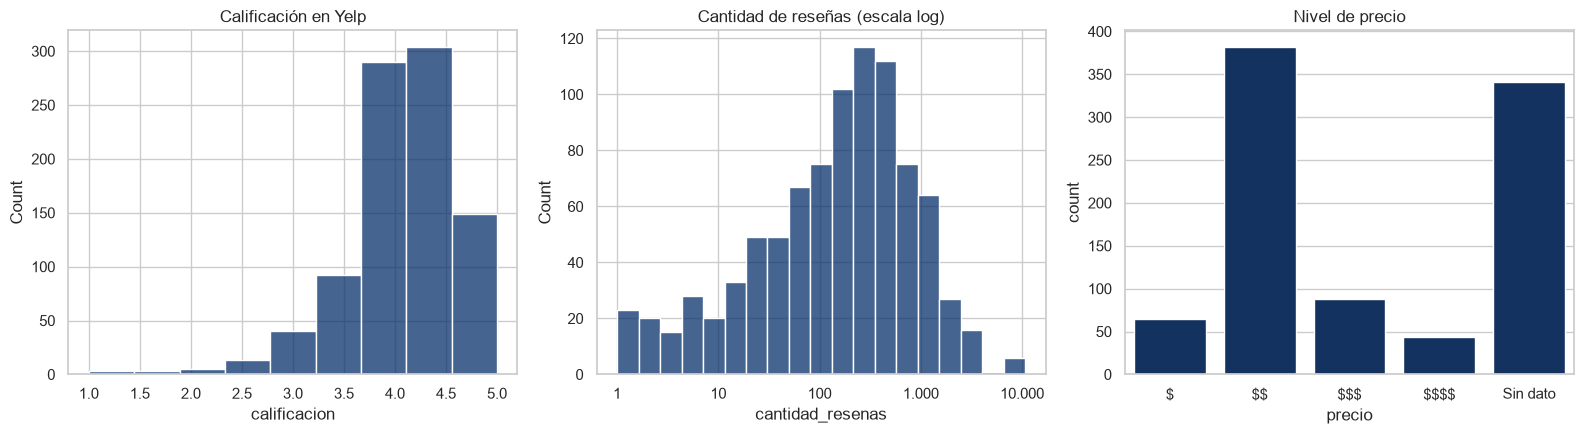

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(df_yelp_limpia_unicos["calificacion"], bins=9, color=COLOR_PRINCIPAL, ax=axes[0])
axes[0].set_title("Calificación en Yelp")

sns.histplot(df_yelp_limpia_unicos["cantidad_resenas"], log_scale=True, color=COLOR_PRINCIPAL, ax=axes[1])
axes[1].set_title("Cantidad de reseñas (escala log)")
# Como "$" se muestra como texto (celda 1), las marcas del eje logarítmico se escriben como números comunes
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda valor, _: f"{valor:,.0f}".replace(",", ".")))

sns.countplot(x=df_yelp_limpia_unicos["precio"].fillna("Sin dato"), order=[*SIMBOLO_PRECIO.values(), "Sin dato"],
              color=COLOR_PRINCIPAL, ax=axes[2])
axes[2].set_title("Nivel de precio")

plt.tight_layout()
plt.show()

### 8.2 Oferta por preferencia alimenticia

In [21]:
oferta_por_preferencia = (
    df_yelp_limpia.groupby("preferencia_cliente")
    .agg(
        negocios_descargados=("id_yelp", "count"),
        calificacion_media=("calificacion", "mean"),
        resenas_mediana=("cantidad_resenas", "median"),
        nivel_precio_medio=("nivel_precio", "mean"),
        porc_con_precio=("nivel_precio", lambda s: s.notna().mean() * 100),
    )
    .round(2)
)
oferta_por_preferencia["total_en_yelp"] = resumen_descarga["total_en_yelp"]
oferta_por_preferencia.sort_values("total_en_yelp", ascending=False)

,negocios_descargados,calificacion_media,resenas_mediana,nivel_precio_medio,porc_con_precio,total_en_yelp
preferencia_cliente,,,,,,
Otro,240,4.35,365.50,2.23,74.58,7900
Mariscos,233,4.02,137.00,2.34,60.94,374
Carnes,229,3.90,142.00,2.61,60.70,293
Pescado,233,4.13,157.00,2.17,61.37,278
Vegano,58,4.13,97.00,1.70,51.72,67
Vegetariano,58,3.88,136.00,1.66,65.52,60


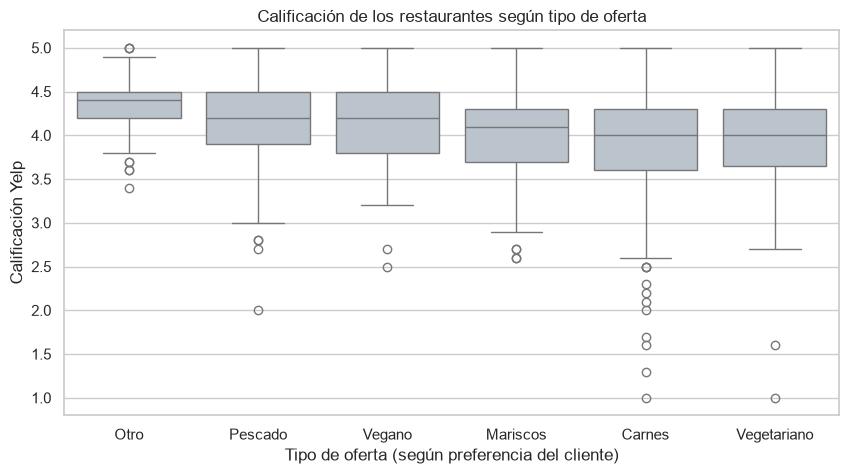

In [22]:
orden_calificacion = oferta_por_preferencia.sort_values("calificacion_media", ascending=False).index

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_yelp_limpia, x="preferencia_cliente", y="calificacion", order=orden_calificacion, color=COLOR_BASE)
plt.title("Calificación de los restaurantes según tipo de oferta")
plt.xlabel("Tipo de oferta (según preferencia del cliente)")
plt.ylabel("Calificación Yelp")
plt.show()

## 9. Integración con la base de clientes

La base de clientes y la de Yelp **no comparten un identificador** (un cliente no es un restaurante), así que no se pueden unir fila a fila. La integración se hace a través de **dos variables en común** que se construyen a propósito:

1. **Preferencia alimenticia** ↔ tipo de oferta de Yelp (ya conectadas en la búsqueda, sección 5).
2. **Nivel de precio**: se traduce el gasto promedio de cada cliente a la escala de precios de Yelp.

### 9.1 Nivel de precio objetivo de cada cliente

Yelp define sus niveles de precio según el gasto aproximado por persona: `$` hasta 10 USD, `$$` de 11 a 30, `$$$` de 31 a 60 y `$$$$` más de 60. Se aplica esa misma escala al `promedio_gasto_comida` de cada cliente con `pd.cut`.

Los clientes con gasto 0 (no visitan restaurantes) quedan sin nivel de precio: no tiene sentido asignarles oferta.

In [23]:
df_restaurantes_trans["nivel_precio_objetivo"] = pd.cut(
    df_restaurantes_trans["promedio_gasto_comida"],
    bins=[0, 10, 30, 60, np.inf],
    labels=[1, 2, 3, 4],
    right=True,                 # (0, 10] -> 1 ; el gasto 0 queda fuera (NaN)
).astype(float)

nivel_precio_texto = df_restaurantes_trans["nivel_precio_objetivo"].map(SIMBOLO_PRECIO).fillna("Sin consumo")
nivel_precio_texto.value_counts().reindex([*SIMBOLO_PRECIO.values(), "Sin consumo"])

nivel_precio_objetivo
$              1446
$$             2130
$$$            1145
$$$$            402
Sin consumo     261
Name: count, dtype: int64

**Verificación de coherencia:** si la traducción es correcta, cada estrato debería concentrarse en un nivel de precio acorde (estrato Bajo en `$`, Muy Alto en `$$$`–`$$$$`).

In [24]:
(pd.crosstab(df_restaurantes_trans["estrato_socioeconomico"], nivel_precio_texto, normalize="index") * 100).round(1)

nivel_precio_objetivo,$,$$,$$$,$$$$,Sin consumo
estrato_socioeconomico,,,,,
Bajo,77.30,0.00,0.00,0.00,22.70
Medio,20.60,79.40,0.00,0.00,0.00
Alto,9.80,34.00,56.30,0.00,0.00
Muy Alto,4.40,20.40,31.80,43.40,0.00


### 9.2 Resumen de la oferta de Yelp por preferencia y nivel de precio

Para cada combinación *preferencia × nivel de precio* se calcula cuántos restaurantes hay, su calificación media, la mediana de reseñas y **el restaurante mejor calificado** (desempatando por cantidad de reseñas), que se usará como sugerencia concreta.

In [25]:
oferta_con_precio = df_yelp_limpia.dropna(subset=["nivel_precio"])

resumen_oferta = (
    oferta_con_precio.groupby(["preferencia_cliente", "nivel_precio"])
    .agg(
        restaurantes_afines=("id_yelp", "count"),
        calificacion_media_afin=("calificacion", "mean"),
        resenas_mediana_afin=("cantidad_resenas", "median"),
    )
    .reset_index()
)

mejor_restaurante = (
    oferta_con_precio.sort_values(["calificacion", "cantidad_resenas"], ascending=False)
    .drop_duplicates(["preferencia_cliente", "nivel_precio"])
    [["preferencia_cliente", "nivel_precio", "nombre", "calificacion"]]
    .rename(columns={"nombre": "restaurante_sugerido", "calificacion": "calificacion_sugerido"})
)

resumen_oferta = resumen_oferta.merge(mejor_restaurante, on=["preferencia_cliente", "nivel_precio"], how="left")
resumen_oferta

,preferencia_cliente,nivel_precio,restaurantes_afines,calificacion_media_afin,resenas_mediana_afin,restaurante_sugerido,calificacion_sugerido
0,Carnes,1.00,12,3.57,91.50,Chicago All Fired Up,4.80
1,Carnes,2.00,62,3.77,403.00,Offset BBQ,4.70
2,Carnes,3.00,33,3.98,800.00,Penumbra,4.80
3,Carnes,4.00,32,4.06,855.50,Bavette's Bar & Boeuf,4.60
4,Mariscos,1.00,17,3.49,127.00,Goose Island Shrimp House Chicago,4.10
5,Mariscos,2.00,77,3.93,296.00,Sunset Phở Caffe,4.70
6,Mariscos,3.00,31,4.11,616.00,Penumbra,4.80
7,Mariscos,4.00,17,4.09,721.00,Bavette's Bar & Boeuf,4.60
8,Otro,1.00,9,4.32,207.00,Beacon Doughnuts,4.70
9,Otro,2.00,126,4.32,543.50,Tepalcates,4.90


### 9.3 Unión: `df_clientes_enriquecido`

Se hace un **`merge` de tipo `left`**: se conservan **todos los clientes**, y a cada uno se le agregan las columnas de la oferta que coincide con su preferencia y su nivel de precio. Si no hay coincidencia, las columnas nuevas quedan vacías.

Luego se crea la columna `estado_oferta`, que explica **por qué** un cliente tiene o no oferta asociada. Así los vacíos no quedan como `NaN` sin interpretación:
- **Con oferta afín**: hay restaurantes de su preferencia en su rango de precio.
- **Sin oferta en su rango de precio**: hay oferta de su preferencia, pero no al precio que suele gastar → posible **oportunidad de mercado**.
- **Preferencia no informada**: el dato faltante del Avance 1 (no se le puede asignar oferta).
- **No consume en restaurantes**: gasto 0.

In [26]:
df_clientes_enriquecido = df_restaurantes_trans.merge(
    resumen_oferta,
    left_on=["preferencias_alimenticias", "nivel_precio_objetivo"],
    right_on=["preferencia_cliente", "nivel_precio"],
    how="left",
).drop(columns=["preferencia_cliente", "nivel_precio"])

# Verificación: el merge no debe duplicar ni perder clientes
assert len(df_clientes_enriquecido) == len(df_restaurantes_trans), "El merge cambió la cantidad de clientes"

condiciones = [
    df_clientes_enriquecido["nivel_precio_objetivo"].isna(),
    df_clientes_enriquecido["preferencias_alimenticias"] == "No informado",
    df_clientes_enriquecido["restaurantes_afines"].isna(),
]
estados = ["No consume en restaurantes", "Preferencia no informada", "Sin oferta en su rango de precio"]
df_clientes_enriquecido["estado_oferta"] = np.select(condiciones, estados, default="Con oferta afín")

# Para quienes consumen y tienen preferencia pero no hay oferta, la cantidad de restaurantes es 0
sin_oferta = df_clientes_enriquecido["estado_oferta"] == "Sin oferta en su rango de precio"
df_clientes_enriquecido.loc[sin_oferta, "restaurantes_afines"] = 0

print(f"Clientes: {len(df_clientes_enriquecido):,} (sin pérdidas ni duplicados)")
df_clientes_enriquecido["estado_oferta"].value_counts()

Clientes: 5,384 (sin pérdidas ni duplicados)


estado_oferta
Con oferta afín                     4474
Sin oferta en su rango de precio     392
No consume en restaurantes           261
Preferencia no informada             257
Name: count, dtype: int64

In [27]:
columnas_vista = ["id_persona", "preferencias_alimenticias", "estrato_socioeconomico", "promedio_gasto_comida",
                  "nivel_precio_objetivo", "estado_oferta", "restaurantes_afines",
                  "calificacion_media_afin", "restaurante_sugerido"]
df_clientes_enriquecido[columnas_vista].sample(8, random_state=1)

,id_persona,preferencias_alimenticias,estrato_socioeconomico,promedio_gasto_comida,nivel_precio_objetivo,estado_oferta,restaurantes_afines,calificacion_media_afin,restaurante_sugerido
1548,5182110973,No informado,Alto,57.39,3.00,Preferencia no informada,NaN,NaN,NaN
3960,8766884198,Vegetariano,Medio,16.70,2.00,Con oferta afín,22.00,4.07,Brightwok Kitchen
4221,2826423231,Otro,Alto,19.71,2.00,Con oferta afín,126.00,4.32,Tepalcates
1626,2476811694,Vegetariano,Medio,26.70,2.00,Con oferta afín,22.00,4.07,Brightwok Kitchen
3485,7846389041,Mariscos,Bajo,7.60,1.00,Con oferta afín,17.00,3.49,Goose Island Shrimp House Chicago
4021,4973774025,Otro,Muy Alto,34.84,3.00,Con oferta afín,37.00,4.27,Ciccio Mio
325,7969660467,Pescado,Alto,23.32,2.00,Con oferta afín,111.00,3.97,Mammoth Poke
2185,5855605194,Otro,Bajo,7.64,1.00,Con oferta afín,9.00,4.32,Beacon Doughnuts


## 10. Primeros resultados de la integración

### 10.1 Demanda de clientes vs. oferta de Yelp

Se compara qué porcentaje de clientes prefiere cada tipo de comida con qué porcentaje de la oferta representa. Para la oferta se usa el **`total` real informado por Yelp** (y no los 240 descargados, que es solo un tope de la API).

El indicador **clientes por cada 100 restaurantes** mide la presión de demanda: un valor alto indica mucha demanda para poca oferta → **oportunidad** para los negocios de ese rubro.

In [28]:
demanda = df_restaurantes_trans["preferencias_alimenticias"].value_counts().drop("No informado", errors="ignore")

# "Otro" es la oferta general de restaurantes: no es comparable con un rubro específico
demanda_vs_oferta = pd.DataFrame({
    "clientes": demanda,
    "restaurantes_en_yelp": resumen_descarga["total_en_yelp"].astype(float),
}).drop("Otro", errors="ignore")

demanda_vs_oferta["porc_clientes"] = (demanda_vs_oferta["clientes"] / demanda_vs_oferta["clientes"].sum() * 100).round(1)
demanda_vs_oferta["porc_oferta"] = (demanda_vs_oferta["restaurantes_en_yelp"] / demanda_vs_oferta["restaurantes_en_yelp"].sum() * 100).round(1)
demanda_vs_oferta["clientes_cada_100_restaurantes"] = (demanda_vs_oferta["clientes"] / demanda_vs_oferta["restaurantes_en_yelp"] * 100).round(1)
demanda_vs_oferta.sort_values("clientes_cada_100_restaurantes", ascending=False)

,clientes,restaurantes_en_yelp,porc_clientes,porc_oferta,clientes_cada_100_restaurantes
Vegetariano,1123,60.00,24.80,5.60,1871.70
Vegano,571,67.00,12.60,6.20,852.20
Carnes,1589,293.00,35.10,27.30,542.30
Pescado,546,278.00,12.10,25.90,196.40
Mariscos,696,374.00,15.40,34.90,186.10


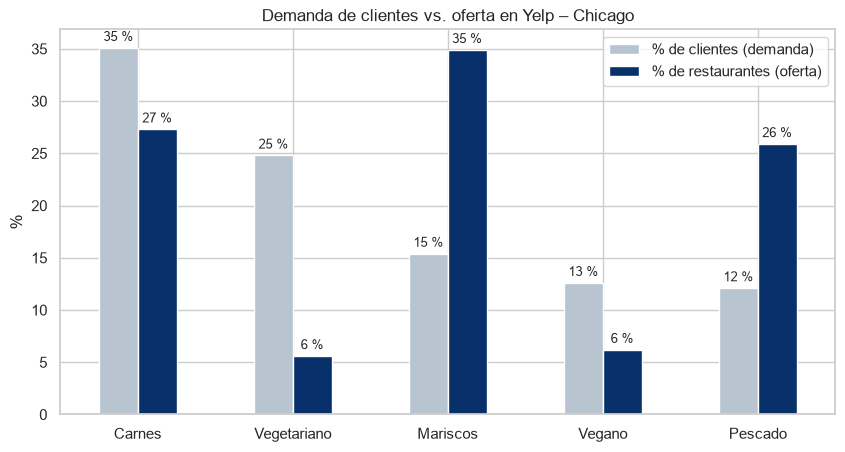

In [29]:
ax = (demanda_vs_oferta.sort_values("porc_clientes", ascending=False)[["porc_clientes", "porc_oferta"]]
      .plot(kind="bar", color=[COLOR_BASE, COLOR_PRINCIPAL], figsize=(10, 5), rot=0))
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.0f %%", padding=3, fontsize=9)
ax.legend(["% de clientes (demanda)", "% de restaurantes (oferta)"])
ax.set_title(f"Demanda de clientes vs. oferta en Yelp – {CIUDAD}")
ax.set_ylabel("%")
ax.set_xlabel("")
plt.show()

> **Nota:** los porcentajes de clientes y de restaurantes no miden lo mismo (personas vs. locales), por eso se comparan las **proporciones** y no las cantidades absolutas. Además, la muestra de clientes es la base de la empresa y no toda la población de Chicago.

**Interpretación:** la comida **vegetariana y vegana** concentra el 37 % de los clientes con preferencia específica, pero solo el 12 % de la oferta: hay **1.872 clientes vegetarianos por cada 100 restaurantes vegetarianos**, diez veces más que en mariscos (186). En cambio, **mariscos y pescado** tienen más peso en la oferta que en la demanda: son mercados más competidos. Para InsightReach esto marca dos estrategias distintas: en rubros con poca oferta, campañas para **captar demanda insatisfecha**; en rubros saturados, campañas de **diferenciación**.

### 10.2 Nivel de precio: lo que gastan los clientes vs. lo que ofrece Yelp

In [30]:
precio_clientes_vs_yelp = pd.DataFrame({
    "porc_clientes": df_restaurantes_trans["nivel_precio_objetivo"].value_counts(normalize=True) * 100,
    "porc_restaurantes": df_yelp_limpia_unicos["nivel_precio"].value_counts(normalize=True) * 100,
}).sort_index().round(1)
precio_clientes_vs_yelp.index = precio_clientes_vs_yelp.index.map(SIMBOLO_PRECIO)
precio_clientes_vs_yelp

,porc_clientes,porc_restaurantes
$,28.20,11.20
$$,41.60,66.00
$$$,22.40,15.20
$$$$,7.80,7.60


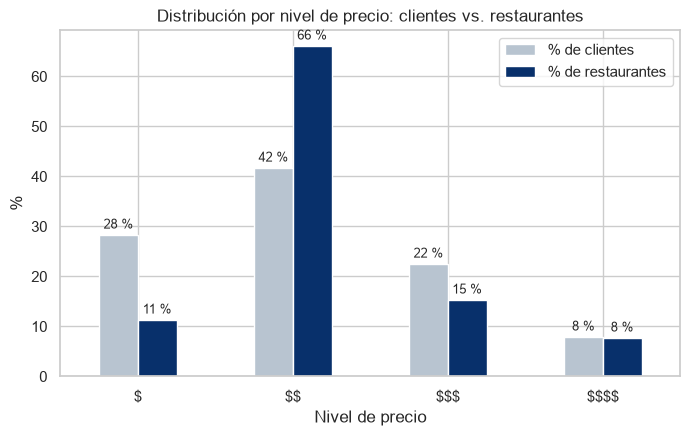

In [31]:
ax = precio_clientes_vs_yelp.plot(kind="bar", color=[COLOR_BASE, COLOR_PRINCIPAL], figsize=(8, 4.5), rot=0)
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.0f %%", padding=3, fontsize=9)
ax.legend(["% de clientes", "% de restaurantes"])
ax.set_title("Distribución por nivel de precio: clientes vs. restaurantes")
ax.set_ylabel("%")
ax.set_xlabel("Nivel de precio")
plt.show()

**Interpretación:** la oferta está muy concentrada en el nivel `$$` (66 % de los restaurantes con precio informado), mientras que los clientes están más repartidos. Los rangos **`$` (28 % de clientes vs. 11 % de restaurantes)** y **`$$$` (22 % vs. 15 %)** tienen menos oferta de la que su demanda justificaría. Hay que tener en cuenta que el 37 % de los restaurantes no informa precio.

### 10.3 Cobertura de la oferta por segmento

In [32]:
tabla_cruzada(df_clientes_enriquecido, "preferencias_alimenticias", "estado_oferta")

estado_oferta,Con oferta afín,No consume en restaurantes,Preferencia no informada,Sin oferta en su rango de precio
preferencias_alimenticias,,,,
Carnes,95.00,5.00,0.00,0.00
Mariscos,96.10,3.90,0.00,0.00
No informado,0.00,4.10,95.90,0.00
Otro,94.20,5.80,0.00,0.00
Pescado,95.60,4.40,0.00,0.00
Vegano,67.80,5.10,0.00,27.10
Vegetariano,73.80,5.10,0.00,21.10


In [33]:
tabla_cruzada(df_clientes_enriquecido, "estrato_socioeconomico", "estado_oferta")

estado_oferta,Con oferta afín,No consume en restaurantes,Preferencia no informada,Sin oferta en su rango de precio
estrato_socioeconomico,,,,
Bajo,74.00,22.70,3.20,0.00
Medio,94.40,0.00,5.60,0.00
Alto,78.50,0.00,4.80,16.70
Muy Alto,79.80,0.00,5.10,15.10


**Interpretación:** los clientes sin oferta en su rango de precio son **todos vegetarianos o veganos** (21 % y 27 % de esos grupos) y pertenecen a los estratos **Alto y Muy Alto**. El motivo: en Yelp no hay restaurantes veganos de nivel `$$$` o `$$$$`, y solo hay un vegetariano `$$$$`. Existe un segmento con alto poder adquisitivo y preferencia *plant-based* que no encuentra oferta acorde. En el estrato Bajo, la falta de oferta no aparece; lo que se ve es que un 23 % no consume en restaurantes.

## 11. Exportación

Se guardan los datos de Yelp limpios y la base de clientes enriquecida, que será la entrada del **Avance 3** (análisis final y recomendaciones).

In [34]:
df_yelp_limpia.to_csv(RUTA_YELP_LIMPIO, index=False)
df_clientes_enriquecido.to_csv(RUTA_ENRIQUECIDO, index=False)
print("Guardados:", RUTA_YELP_LIMPIO, "y", RUTA_ENRIQUECIDO)

Guardados: ../ARCHIVOS/yelp_chicago_negocios.csv y ../ARCHIVOS/clientes_chicago_enriquecido.csv


## 12. Conclusiones del Avance 2

**Sobre la conexión y los datos obtenidos**
- La conexión con la API de Yelp fue exitosa (código 200). Según Yelp, Chicago tiene **7.900 restaurantes**.
- Se hizo **una búsqueda por cada preferencia alimenticia** de los clientes y se obtuvieron 1.087 registros (950 negocios únicos) con nombre, categorías, calificación, cantidad de reseñas, precio y ubicación. Tras la limpieza quedaron **920 restaurantes únicos de la ciudad de Chicago**.
- Los límites de la API (50 resultados por petición y 240 por búsqueda) se resolvieron con paginación. Las búsquedas de vegetariano (60) y vegano (67) se descargaron **completas**; en carnes, mariscos y pescado se obtuvo una muestra de 240 y se usó el `total` informado por Yelp para medir el tamaño real de la oferta.
- Los datos externos también necesitaron limpieza: 35 negocios de localidades vecinas, calificaciones 0 que en realidad significan "sin calificación", categorías repetidas y un **37 % de restaurantes sin precio informado**, que no se imputó.

**Sobre la integración**
- Las fuentes no comparten identificador, así que se integraron con **dos variables puente**: preferencia alimenticia y nivel de precio. La verificación con el estrato confirma que la traducción del gasto a la escala de Yelp es coherente: el 77 % del estrato Bajo cae en `$`, el 79 % del Medio en `$$`, el 56 % del Alto en `$$$` y el nivel `$$$$` aparece solo en el estrato Muy Alto.
- Los 5.384 clientes se conservaron en la unión (sin pérdidas ni duplicados). El **83 %** tiene oferta afín a su preferencia y su presupuesto, con un restaurante sugerido concreto.

**Hallazgos principales**
1. **La mayor oportunidad está en la comida vegetariana y vegana.** Estos clientes son el 37 % de los que tienen una preferencia específica, pero en Yelp representan solo el 12 % de la oferta. Hay **1.872 clientes vegetarianos por cada 100 restaurantes vegetarianos** y 852 veganos por cada 100 veganos, contra 186 en mariscos.
2. **El segmento vegetariano/vegano de alto poder adquisitivo no tiene oferta.** Los 392 clientes (7,3 %) sin oferta en su rango de precio son **todos vegetarianos o veganos**, y se concentran en los estratos Alto (16,7 % del estrato) y Muy Alto (15,1 %). En Chicago no hay restaurantes veganos de nivel `$$$` o `$$$$`, y solo hay un vegetariano `$$$$`: existe demanda premium *plant-based* sin atender.
3. **Mariscos y pescado tienen la situación inversa:** mucha oferta en relación con sus clientes (35 % y 26 % de la oferta frente a 15 % y 12 % de los clientes). Son mercados más competidos, donde un negocio necesita diferenciarse para captar clientes.
4. **Desajuste de precios:** el 28 % de los clientes gasta en rango `$`, pero solo el 11 % de los restaurantes con precio informado está en ese nivel. En el rango `$$$` también hay más clientes (22 %) que oferta (15 %). En cambio, el nivel `$$` está sobreofertado (66 % de los restaurantes frente a 42 % de los clientes).

**Limitaciones**
- Yelp etiqueta como vegetariano o vegano solo a los locales especializados. Muchos restaurantes ofrecen opciones sin plato de carne sin tener esa etiqueta, por lo que la oferta para estos clientes probablemente está **subestimada**. Aun así, la brecha es tan grande que el hallazgo se sostiene.
- Las cantidades de restaurantes por nivel de precio en carnes, mariscos y pescado provienen de una muestra de 240 (tope de la API), no del total.
- La base de clientes representa a la cartera de la empresa, no a toda la población de Chicago.

**Próximo paso (Avance 3):** formular preguntas de negocio sobre esta base integrada y convertir estos hallazgos en propuestas de segmentación concretas para las campañas.